<a href="https://colab.research.google.com/github/Kadakol/ML/blob/master/micrograd/Micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

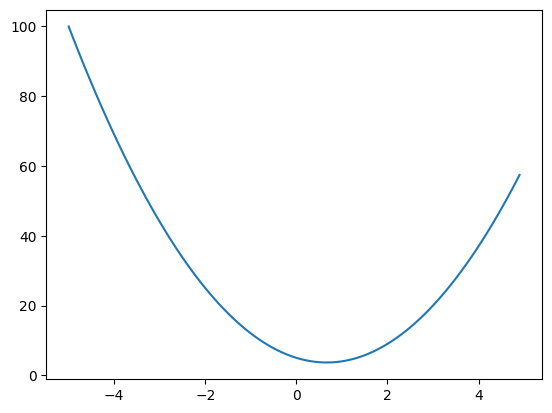

In [4]:
xs = np.arange(-5.0, 5.0, 0.1)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 1e-12
x = 3.0
(f(x+h) - f(x)) / h

14.001244608152774

In [6]:
h = 1e-12
x = -3.0
(f(x+h) - f(x))/h

-21.9984030991327

In [7]:
h = 1e-12
x = 2/3
(f(x+h) - f(x))/h

-0.0004440892098500626

In [8]:
a = 2
b = -3
c = 10
d = a*b + c
print(d)

4


In [9]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 3.9999699999999994
slope : -3.000000000064062


In [10]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 4.00002
slope : 2.0000000000131024


In [11]:
h = 1e-5

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print(f'd1 : {d1}')
print(f'd2 : {d2}')
print(f'slope : {(d2-d1)/h}')

d1 : 4.0
d2 : 4.00001
slope : 0.9999999999621422


In [12]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f'Value(label={self.label}, data={self.data})'

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

print(a + b)
print(a * b)
print(a * b + c)

Value(label=, data=-1.0)
Value(label=, data=-6.0)
Value(label=, data=4.0)


In [13]:
d = a * b + c
print(d)
print(d._prev)
print(d._op)

Value(label=, data=4.0)
{Value(label=, data=-6.0), Value(label=c, data=10.0)}
+


In [14]:
e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label='L'

print(L)

Value(label=L, data=-8.0)


In [15]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
  """
  format: png | svg | ...
  rankdir: TB (top to bottom graph) | LR (left to right)
  """
  assert rankdir in ['LR', 'TB']
  nodes, edges = trace(root)
  dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

  for n in nodes:
    dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name=str(id(n)) + n._op, label=n._op)
      dot.edge(str(id(n)) + n._op, str(id(n)))

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

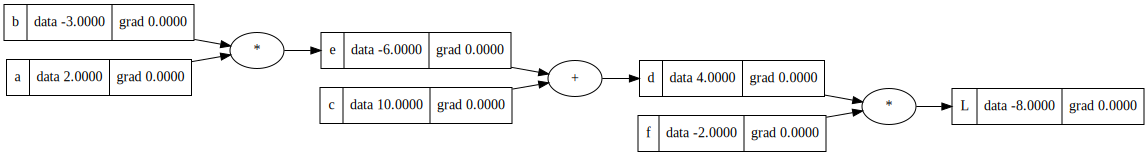

In [16]:
draw_dot(L)

In [17]:
def lol():
  h = 0.0001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d = e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d * f; L.label='L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  # a.data += h
  # b.data += h
  e = a*b; e.label='e'
  # c.data += h
  # e.data += h
  d = e + c; d.label='d'
  # d.data += h
  f = Value(-2.0, label='f')
  L = d * f; L.label='L'
  # L.data += h
  L2 = L.data

  print((L2 - L1) / h)

lol()

0.0


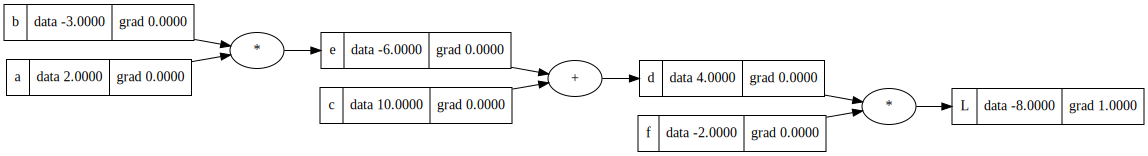

In [18]:
L.grad = 1.0
draw_dot(L)

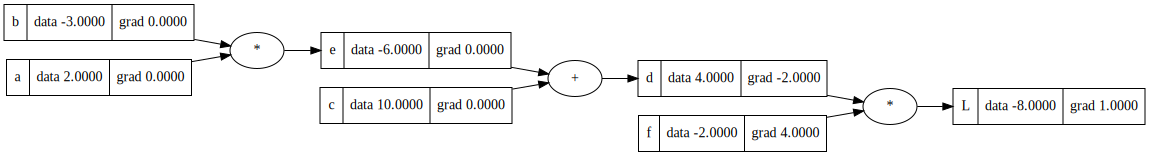

In [19]:
f.grad = 4.0 # =d
d.grad = -2.0 # = f

draw_dot(L)

# how to compute grad of L with c?

dd / dc = ?

d = c + e

(f(x+h) - f(x))/h

((c+h +e) - (c + e))/h

h/h

1.0

dd / dc = 1.0

dd / de = 1.0


WANT:
dL / dc

KNOW:
dL / dd
dd / dc

dL / dc = (dL / dd) * (dd / dc)

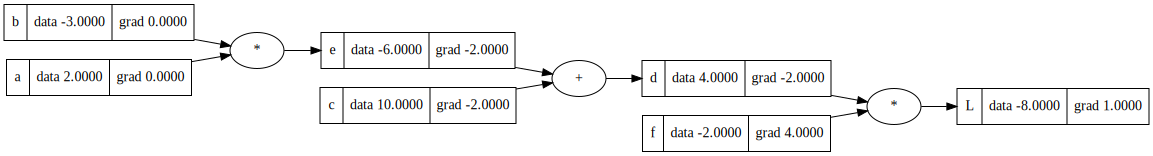

In [20]:
c.grad = -2.0
e.grad = -2.0

draw_dot(L)

dL / de = -2.0

WANT:
dL/da = (dL / de) * (de / da)


e = a * b
de/da = b = -3.0
de/db = a = -2.0


dL / da = -2.0 * -3.0
dL / db = -2.0 * 2.0

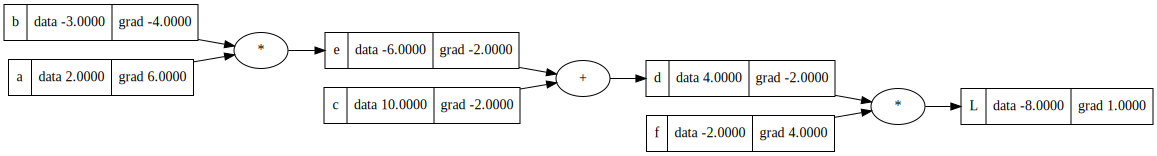

In [21]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

draw_dot(L)

In [22]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(a.data, b.data, c.data, e.data, d.data, L.data)

print(L.data)

2.06 -3.04 9.98 -6.2624 3.7176 -7.286496
-7.286496


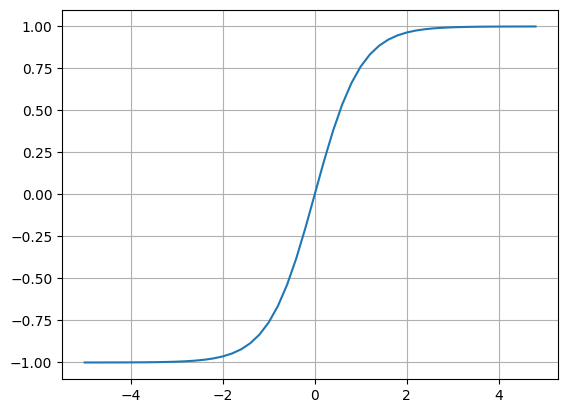

In [23]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [24]:
# Inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias of the neuron
b = Value(6.8813735870195432, label='b')
# b = Value(6.88, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

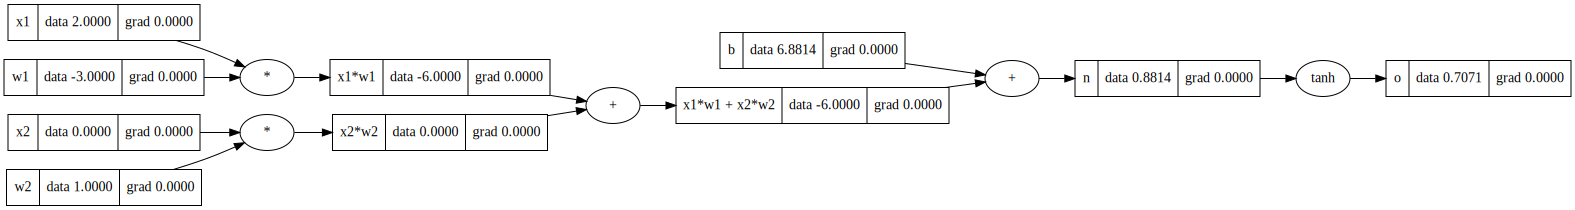

In [25]:
draw_dot(o)

In [26]:
# o.grad = 1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# w1._backward()
# w2._backward()

In [27]:
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

In [28]:
# x1w1.grad = 0.5
# x2w2.grad = 0.5

In [29]:
# x1w1x2w2.grad = 0.5
# b.grad = 0.5

In [30]:
# n.grad = 0.5

In [31]:
# o.grad = 1.0

In [32]:
# 1 - o.data**2

o = tanh(n)

do / dn = 1 - tanh(n)**2

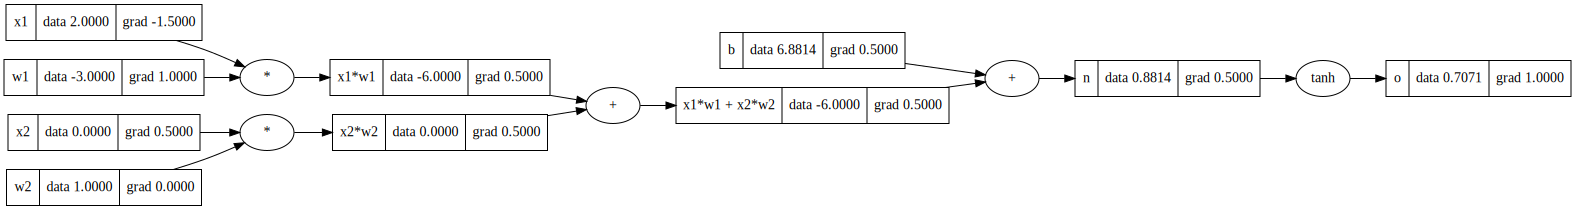

In [33]:
o.backward()
draw_dot(o)

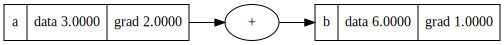

In [34]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

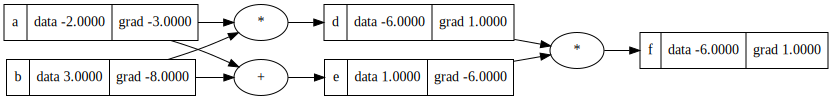

In [35]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)